## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt

#CHANGE AS NEEDED
sys.path.append('/home/patrick/ansermodelling')
os.chdir("/home/patrick/ansermodelling")


from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train


## Dataset

In [2]:
dataset = AnserDataset("data/dataset.npz")

### Spatial Distribution

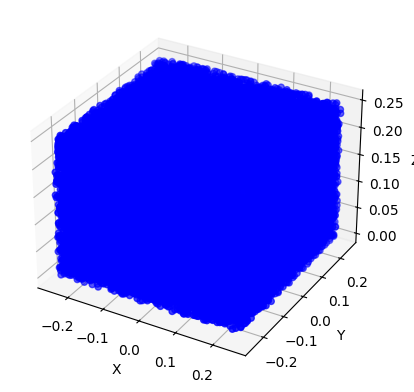

In [3]:
positions = dataset.y[:,:3]

# Create a new figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create a scatter plot
ax.scatter(positions[:,0], positions[:,1], positions[:,2], c='blue', marker='o')

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Show the plot
plt.show()

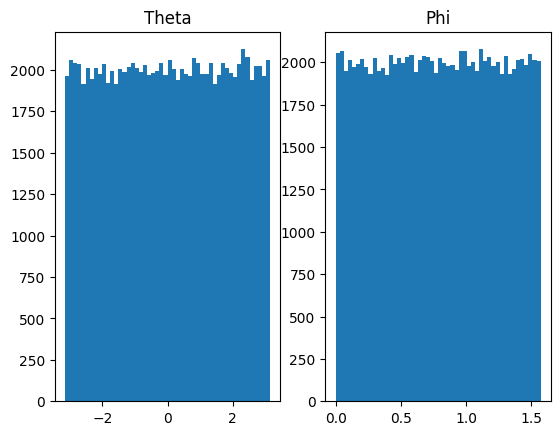

In [4]:
theta = dataset.y[:, 3]
phi = dataset.y[:, 4]

fig, axes = plt.subplots(1, 2)
axes[0].hist(theta, bins=50)
axes[0].set_title("Theta")
axes[1].hist(phi, bins=50)
axes[1].set_title("Phi")
plt.show()

Distrubtion of Fluxes

0.005366849
12.792672


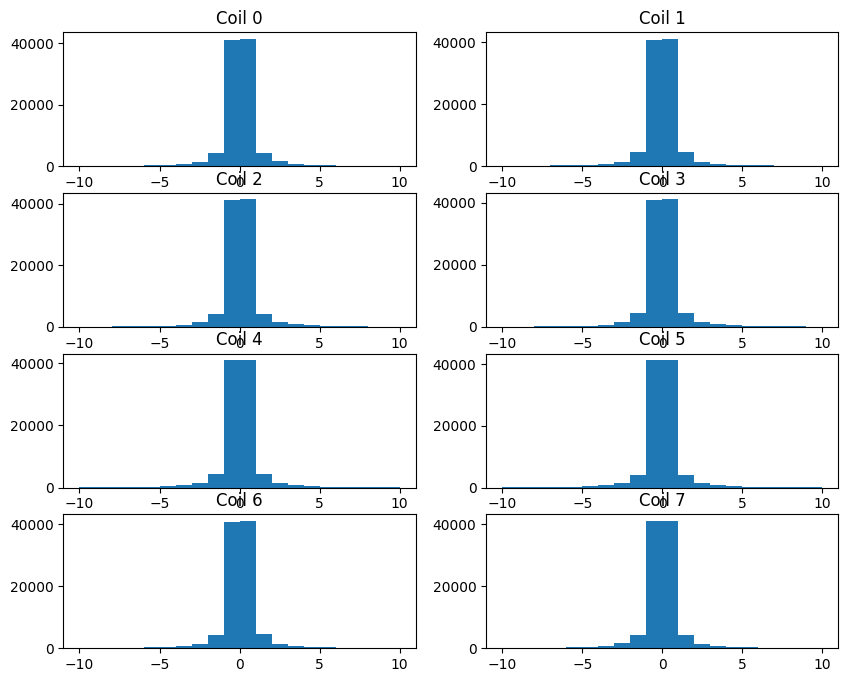

In [5]:
fluxes = dataset.x.numpy()
fig, axes = plt.subplots(4, 2, figsize=(10, 8))

print(np.mean(fluxes))
print(np.std(fluxes))

for ax, i in zip(axes.flat, range(8)):
    ax.hist(fluxes[:, i], bins=20,range=(-10, 10))
    ax.set_title(f"Coil {i}")
plt.show()

In [6]:
from torch.utils.data import random_split
n = len(dataset)
n_train = int(0.8 * n)
n_test = n - n_train

train_set, test_set = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [7]:
model = FFNN(input_dim=8, output_dim=5, hidden_dims=[64,256,64])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
train_losses, test_losses = train(model, train_loader, test_loader, optimizer, epochs=100, print_losses = True)

Epoch 0, train loss: 0.0051, test loss: 0.0066
Epoch 1, train loss: 0.0051, test loss: 0.0061
Epoch 2, train loss: 0.0051, test loss: 0.0066
Epoch 3, train loss: 0.0051, test loss: 0.0061
Epoch 4, train loss: 0.0050, test loss: 0.0065
Epoch 5, train loss: 0.0050, test loss: 0.0061
Epoch 6, train loss: 0.0050, test loss: 0.0063
Epoch 7, train loss: 0.0051, test loss: 0.0063
Epoch 8, train loss: 0.0050, test loss: 0.0064
Epoch 9, train loss: 0.0050, test loss: 0.0062
Epoch 10, train loss: 0.0051, test loss: 0.0061
Epoch 11, train loss: 0.0050, test loss: 0.0063
Epoch 12, train loss: 0.0050, test loss: 0.0063
Epoch 13, train loss: 0.0050, test loss: 0.0063
Epoch 14, train loss: 0.0050, test loss: 0.0062
Epoch 15, train loss: 0.0050, test loss: 0.0061
Epoch 16, train loss: 0.0050, test loss: 0.0064
Epoch 17, train loss: 0.0050, test loss: 0.0061
Epoch 18, train loss: 0.0050, test loss: 0.0061
Epoch 19, train loss: 0.0050, test loss: 0.0062
Epoch 20, train loss: 0.0049, test loss: 0.0060
Ep

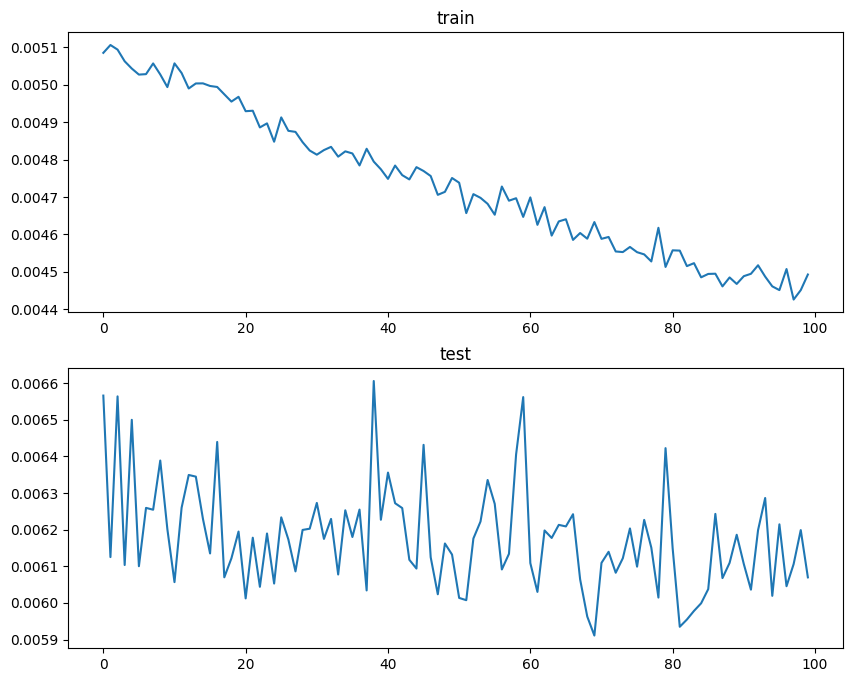

In [11]:
fig, axes = plt.subplots(2,figsize=(10, 8))
axes[0].plot(train_losses)
axes[0].set_title("train")
axes[1].plot(test_losses)
axes[1].set_title("test")
plt.show()


Looks like I might be overfitting. I think I might normalise the data 